# Agrupamento de variedades de arroz

A base de dados é composta por **45** características e **2'091** entradas.


In [7]:
%%html
<link rel="stylesheet" href="./style.css">

In [ ]:
import import_ipynb  # noqa: F401
from treatment import f2_df, f_categorical_columns, f_numeric_columns  # type: ignore


In [9]:
import matplotlib.pyplot as plt
from kmodes.kprototypes import KPrototypes
from sklearn.decomposition import PCA

In [10]:
# Identify indexes of categorical indexes
indexes_of_categorical_columns = [
    f2_df.columns.get_loc(col) for col in f_categorical_columns
]

In [ ]:
clustered_df_through_kp = f2_df.copy()

k_prototypes_protocol = KPrototypes(n_clusters=4, random_state=42)

clusters = k_prototypes_protocol.fit_predict(
    clustered_df_through_kp, categorical=indexes_of_categorical_columns
)

# Add column describing the cluster to the database
clustered_df_through_kp["Cluster"] = clusters


Número de clusters: 2
Número de variáveis: 17

Centroides:
[['-1.0299044056978457' '0.00670010723301023' '-0.0225430854733173'
  '0.0015846408315698963' '-0.0061417517240256805' '0.017448764232034154'
  '197.9243119266055' '12608.915137614678' '-0.0038764496543623366'
  '-0.016670038026425398' '-0.009024717136804793' '-0.017368162414816334'
  '0.0045071275120039875' 'Sankarapuram' 'ponmani' 'clay' 'dry']
 ['0.7367322738051901' '-0.004792857676106952' '0.01612598074875637'
  '-0.001133557674429703' '0.004393443398974554' '-0.012481806735304234'
  '427.3995077932732' '29288.723543888435' '0.0027729812129920132'
  '0.01192475238641669' '0.006455745154464229' '0.012424148995668254'
  '-0.0032241305910303032' 'Sankarapuram' 'delux ponni' 'clay' 'dry']]


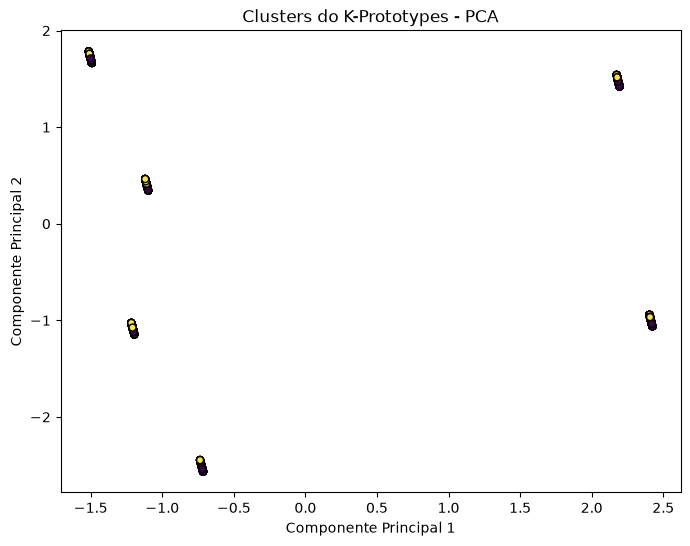

In [12]:
centroides = k_prototypes_protocol.cluster_centroids_

print("Número de clusters:", k_prototypes_protocol.n_clusters)
print("Número de variáveis:", len(clustered_df_through_kp.columns) - 1)

print("\nCentroides:")
print(centroides)


pca = PCA(n_components=2)

xn = pca.fit_transform(clustered_df_through_kp[f_numeric_columns])
plt.figure(figsize=(8, 6))

plt.scatter(xn[:, 0], xn[:, 1], marker="o", c=clusters, s=25, edgecolor="k")

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Clusters do K-Prototypes - PCA")

plt.show()